# Exploratory Data Analysis
## Ryan Waterman and JR Fon

### Imports

In [87]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

In [88]:
data_path = os.path.join(*Path.cwd().parts[:-1],"data")

### Read in data from csv files

In [89]:
df = pd.DataFrame()
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        file_path = os.path.join(data_path, file)
        temp_df = pd.read_csv(file_path)
        df = pd.concat([df, temp_df], ignore_index=True)
len(df)

4440384

In [90]:
df.head(5)

,Date,z [m/s2],x [m/s2],y [m/s2],T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C],Altitude [m]
0,2023-01-31 14:00:01,0.000206,0.000166,0.000148,19.791454,19.863238,19.958212,19.611312,19.782525,19.910947,19.686221,19.866912,19.779195,19.822539,20.083956,20.553056,56.501111
1,2023-01-31 14:00:02,0.000206,0.000166,0.000149,19.791452,19.863260,19.958182,19.611313,19.782551,19.910995,19.686290,19.866992,19.779090,19.822577,20.084072,20.560000,56.505000
2,2023-01-31 14:00:03,0.000205,0.000166,0.000149,19.791477,19.863239,19.958230,19.611286,19.782511,19.910869,19.686390,19.867029,19.779148,19.822605,20.084086,20.553500,56.512875
3,2023-01-31 14:00:04,0.000206,0.000166,0.000148,19.791416,19.863226,19.958226,19.611257,19.782615,19.910896,19.686423,19.866973,19.779131,19.822622,20.084077,20.559625,56.511875
4,2023-01-31 14:00:05,0.000207,0.000166,0.000149,19.791399,19.863232,19.958224,19.611407,19.782624,19.910894,19.686496,19.866928,19.779156,19.822597,20.084086,20.556125,56.509250


### Remove the date column

In [91]:
df.drop(columns=['Date'], inplace=True)
df.head(5)

,z [m/s2],x [m/s2],y [m/s2],T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C],Altitude [m]
0,0.000206,0.000166,0.000148,19.791454,19.863238,19.958212,19.611312,19.782525,19.910947,19.686221,19.866912,19.779195,19.822539,20.083956,20.553056,56.501111
1,0.000206,0.000166,0.000149,19.791452,19.863260,19.958182,19.611313,19.782551,19.910995,19.686290,19.866992,19.779090,19.822577,20.084072,20.560000,56.505000
2,0.000205,0.000166,0.000149,19.791477,19.863239,19.958230,19.611286,19.782511,19.910869,19.686390,19.867029,19.779148,19.822605,20.084086,20.553500,56.512875
3,0.000206,0.000166,0.000148,19.791416,19.863226,19.958226,19.611257,19.782615,19.910896,19.686423,19.866973,19.779131,19.822622,20.084077,20.559625,56.511875
4,0.000207,0.000166,0.000149,19.791399,19.863232,19.958224,19.611407,19.782624,19.910894,19.686496,19.866928,19.779156,19.822597,20.084086,20.556125,56.509250


### Determine missingness

In [92]:
missing_counts = df.isna().sum()
missing_percentages = df.isna().mean() * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentages
}).sort_values(by='Missing Percentage', ascending=False)

print(missing_summary[missing_summary['Missing Count'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


## Descriptive Statistics

In [93]:
summary_stats = df.describe().T

summary_stats['skew'] = df.skew()
summary_stats['kurtosis'] = df.kurtosis()

target_cols = ['z [m/s2]', 'x [m/s2]', 'y [m/s2]']
target_table = summary_stats.loc[target_cols]
display(target_table) 

temp_cols = [col for col in df.columns if 'C]' in col]
temp_table = summary_stats.loc[temp_cols]
display(temp_table) 

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
z [m/s2],4440384.0,1.670793e-08,0.000848,-0.003595,-0.000511,0.000125,0.000495,0.001969,-0.602076,0.777963
x [m/s2],4440384.0,3.367185e-09,0.000093,-0.000349,-0.000050,0.000025,0.000062,0.000223,-1.806072,4.697008
y [m/s2],4440384.0,4.950512e-09,0.000073,-0.000178,-0.000059,0.000016,0.000053,0.000237,-0.422142,-0.465887


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
T z [C],4440384.0,20.119444,1.083128,17.040667,19.362459,20.189339,20.709977,25.023437,0.345833,1.188226
T x [C],4440384.0,20.145729,1.088315,17.096928,19.393226,20.200823,20.725749,25.337893,0.450802,1.445051
T y [C],4440384.0,20.194293,1.087148,17.182475,19.433556,20.243314,20.777328,25.185821,0.475450,1.372927
bottom x1 side [C],4440384.0,19.963638,1.106978,16.883326,19.210527,20.016932,20.548922,25.293709,0.489108,1.580954
x sensor face [C],4440384.0,20.079720,1.126830,17.000634,19.323837,20.110357,20.647037,27.664388,0.657486,2.287972
y sensor face [C],4440384.0,20.348280,1.149334,17.113571,19.570549,20.412572,20.971432,27.214691,0.486436,1.844882
bottom x2 side [C],4440384.0,20.033160,1.115313,16.937980,19.277999,20.082995,20.619902,25.680091,0.513119,1.675913
x elect face [C],4440384.0,20.153117,1.111769,17.075413,19.405628,20.197059,20.730796,27.192719,0.577851,2.043646
y ACQ face [C],4440384.0,20.086195,1.110763,16.990940,19.336295,20.137453,20.674439,26.190508,0.523253,1.837203
top [C],4440384.0,20.111126,1.147182,16.996185,19.343809,20.137853,20.678508,28.097366,0.686511,2.249667


## Collinearity Assessment

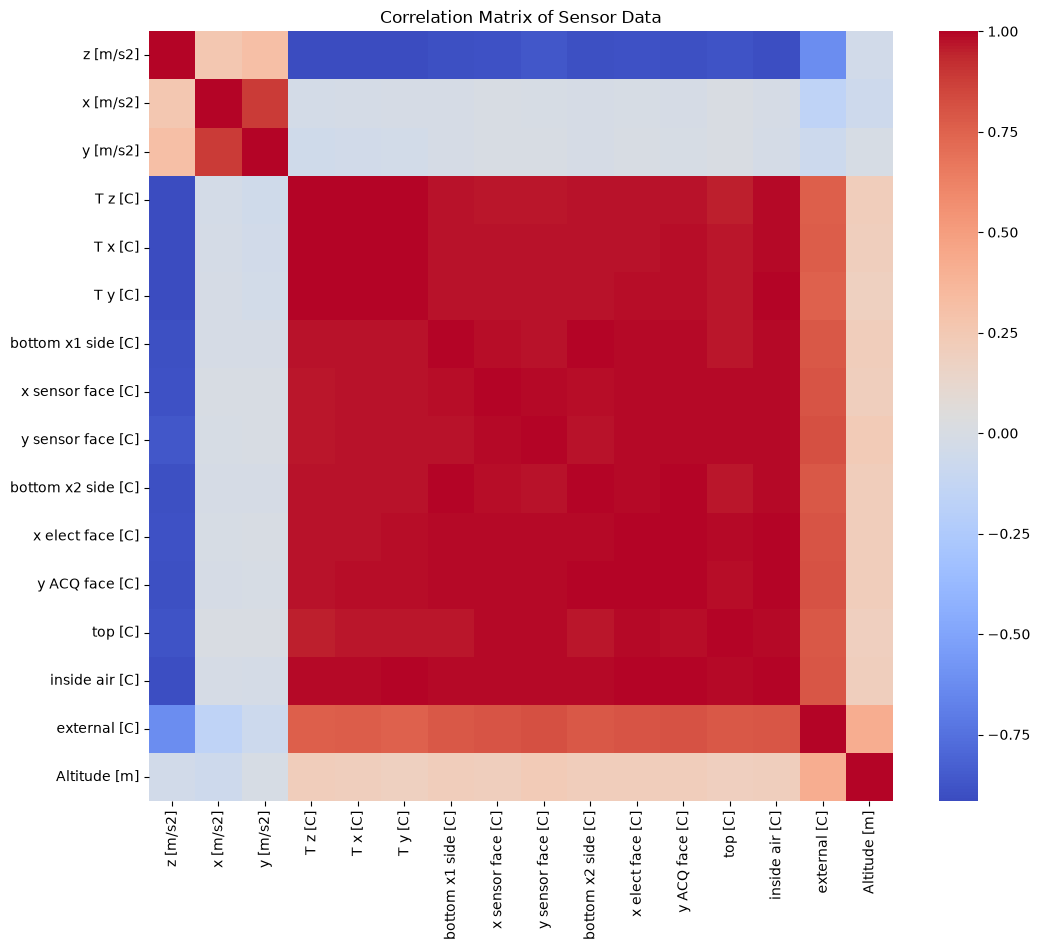

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate a correlation matrix
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Sensor Data")
plt.show()

## Generate Graphs of data

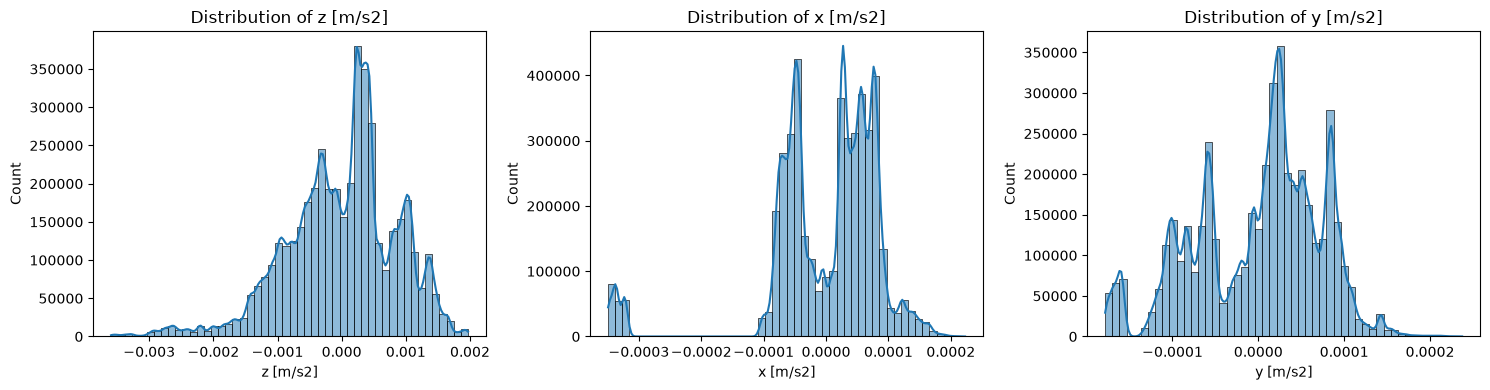

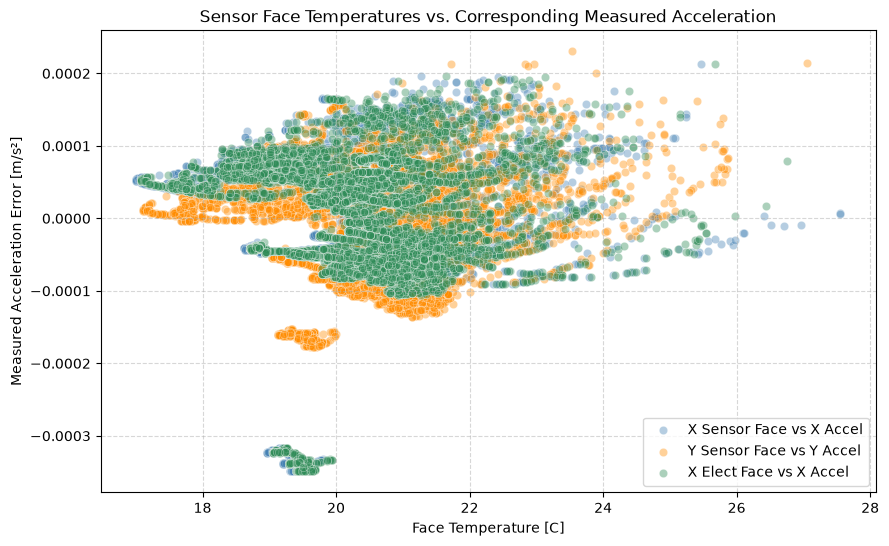

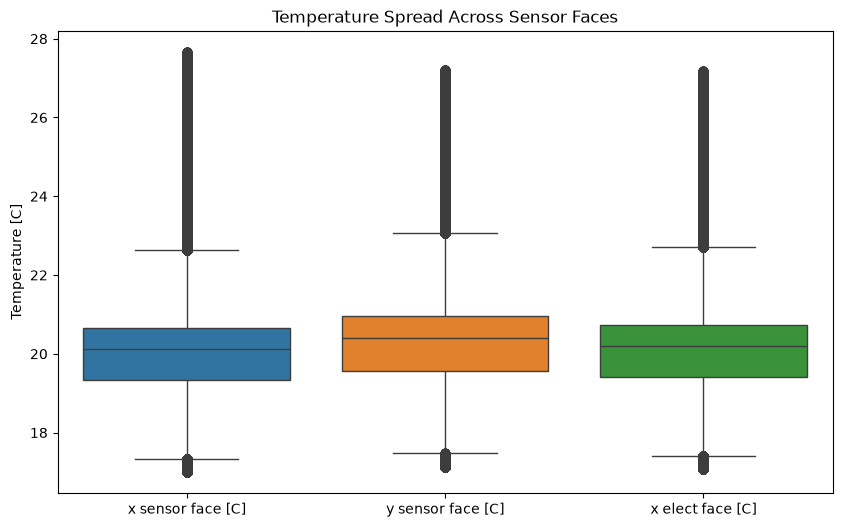

In [ ]:
# Histograms of the target error distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(target_cols):
    sns.histplot(df[col], bins=50, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

"""# Scatterplot showing relationship between external temp and internal air temp
plt.figure(figsize=(8, 5))
sns.scatterplot(x='external [C]', y='inside air [C]', data=df, alpha=0.1)
plt.title("External vs. Inside Air Temperature")
plt.show()"""

# Scatterplots of sensor face temperatures vs. corresponding measured acceleration
plt.figure(figsize=(10, 6))

# Sample the dataframe to prevent the notebook from hanging on 4.4M points
df_sample = df.sample(n=10000, random_state=42)

# Plot X sensor face temp vs X acceleration
sns.scatterplot(x='x sensor face [C]', y='x [m/s2]', data=df_sample, 
                color='steelblue', alpha=0.4, label='X Sensor Face vs X Accel')

# Plot Y sensor face temp vs Y acceleration
sns.scatterplot(x='y sensor face [C]', y='y [m/s2]', data=df_sample, 
                color='darkorange', alpha=0.4, label='Y Sensor Face vs Y Accel')

# Plot X electronics face temp vs X acceleration
sns.scatterplot(x='x elect face [C]', y='x [m/s2]', data=df_sample, 
                color='seagreen', alpha=0.4, label='X Elect Face vs X Accel')

plt.title("Sensor Face Temperatures vs. Corresponding Measured Acceleration")
plt.xlabel("Face Temperature [C]")
plt.ylabel("Measured Acceleration Error [m/s²]")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Boxplots to compare temperature spreads across different sensor faces
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['x sensor face [C]', 'y sensor face [C]', 'x elect face [C]']])
plt.title("Temperature Spread Across Sensor Faces")
plt.ylabel("Temperature [C]")
plt.show()

### Train a naive GLM on the existing data

The output of the model will have to be a vector predicting the error in each of the cartesian directions. To achieve this, utilize a multi-output regressor and a poisson regressor linear model. First, the independent variables will need to be joined into a single array for each observation.

In [96]:
df["error_array"] = df[[ "x [m/s2]", "y [m/s2]", "z [m/s2]"]].values.tolist()
df["error_array"].head(10)

0    [0.0001656771768882, 0.0001482830850121, 0.000...
1    [0.000165663565777, 0.000148740973901, 0.00020...
2    [0.000165898065777, 0.000149356973901, 0.00020...
3    [0.000165621065777, 0.000148172473901, 0.00020...
4    [0.000165855065777, 0.000149073473901, 0.00020...
5    [0.000165645065777, 0.000148529973901, 0.00020...
6    [0.000165856565777, 0.000148870473901, 0.00020...
7    [0.000165709065777, 0.000149072473901, 0.00020...
8    [0.000165618565777, 0.000148228473901, 0.00020...
9    [0.000165932065777, 0.000149164973901, 0.00020...
Name: error_array, dtype: object

In [97]:
df.drop(columns=['x [m/s2]', 'y [m/s2]', 'z [m/s2]'], inplace=True)

In [98]:
df.head(5)

,T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C],Altitude [m],error_array
0,19.791454,19.863238,19.958212,19.611312,19.782525,19.910947,19.686221,19.866912,19.779195,19.822539,20.083956,20.553056,56.501111,"[0.0001656771768882, 0.0001482830850121, 0.000..."
1,19.791452,19.863260,19.958182,19.611313,19.782551,19.910995,19.686290,19.866992,19.779090,19.822577,20.084072,20.560000,56.505000,"[0.000165663565777, 0.000148740973901, 0.00020..."
2,19.791477,19.863239,19.958230,19.611286,19.782511,19.910869,19.686390,19.867029,19.779148,19.822605,20.084086,20.553500,56.512875,"[0.000165898065777, 0.000149356973901, 0.00020..."
3,19.791416,19.863226,19.958226,19.611257,19.782615,19.910896,19.686423,19.866973,19.779131,19.822622,20.084077,20.559625,56.511875,"[0.000165621065777, 0.000148172473901, 0.00020..."
4,19.791399,19.863232,19.958224,19.611407,19.782624,19.910894,19.686496,19.866928,19.779156,19.822597,20.084086,20.556125,56.509250,"[0.000165855065777, 0.000149073473901, 0.00020..."


### Create target and predictor arrays for GLM training

In [99]:
X = np.array(df.drop(columns=['error_array']))
y = np.array(df['error_array'].tolist())

### Randomly sample observations for training and test

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

### Train linear regression model

In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor

In [102]:
glm = MultiOutputRegressor(LinearRegression())
glm.fit(X_train, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,LinearRegression()
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary <n_jobs>` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
Name,Type,Value
estimators_ estimators_: list of ``n_output`` estimatorsEstimators used for predictions.,list,"[LinearRegression(), LinearRegression(), LinearRegression()]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying `estimator` exposes such an attribute when fit... versionadded:: 0.24,int,13
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [103]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

class RegressionEvaluator():
    def __init__(self, fit_model=None):
        self.model = fit_model
    
    def eval_model(self, X_test, y_test, target_names=None):
        assert self.model is not None, "Model must be provided."
        self.novel_x = X_test
        self.novel_y = np.array(y_test)
        self.target_names = target_names
        
        # Get raw predictions
        self.predictions = self.model.predict(X_test)

        self._describe_predictions()
        self._compute_metrics()
        self._plot_results()

    def _describe_predictions(self):
        print("--- Prediction Statistics ---")
        print(f"Mean Prediction: {np.mean(self.predictions):.4f}")
        print(f"Min Prediction:  {np.min(self.predictions):.4f}")
        print(f"Max Prediction:  {np.max(self.predictions):.4f}")
        print(f"Std Deviation:   {np.std(self.predictions):.4f}\n")

    def _compute_metrics(self):
        # Calculate aggregate overall metrics
        self.mse = mean_squared_error(self.novel_y, self.predictions)
        self.rmse = np.sqrt(self.mse)
        self.mae = mean_absolute_error(self.novel_y, self.predictions)
        self.r2 = r2_score(self.novel_y, self.predictions)

        print(f'--- Overall Model Performance ---')
        print(f'Mean Squared Error (MSE):      {self.mse:.4f}')
        print(f'Root Mean Squared Error (RMSE): {self.rmse:.4f}')
        print(f'Mean Absolute Error (MAE):     {self.mae:.4f}')
        print(f'R-squared (R2):                {self.r2:.4f}')

        # If the target is multi-output (e.g., a 2D matrix of [x, y, z]), evaluate each axis
        if self.novel_y.ndim > 1 and self.novel_y.shape[1] > 1:
            mse_raw = mean_squared_error(self.novel_y, self.predictions, multioutput='raw_values')
            r2_raw = r2_score(self.novel_y, self.predictions, multioutput='raw_values')
            
            print(f'\n--- Per-Target Performance ---')
            for i, (m, r) in enumerate(zip(mse_raw, r2_raw)):
                name = self.target_names[i] if self.target_names else f'Target {i}'
                print(f'{name} -> MSE: {m:.4f} | R2: {r:.4f}')

    def _plot_results(self):
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Flatten arrays so plotting works natively whether the target is 1D or a 3D multi-output matrix
        y_flat = self.novel_y.flatten()
        preds_flat = self.predictions.flatten()
        
        # Calculate residuals
        residuals = y_flat - preds_flat

        # Plot 1: True vs Predicted
        axes[0].scatter(y_flat, preds_flat, alpha=0.5, edgecolor='k')
        
        # Plot ideal y=x line
        min_val = min(np.min(y_flat), np.min(preds_flat))
        max_val = max(np.max(y_flat), np.max(preds_flat))
        axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit')
        
        axes[0].set_title('True vs. Predicted Values')
        axes[0].set_xlabel('True Values')
        axes[0].set_ylabel('Predicted Values')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.7)

        # Plot 2: Residuals vs Predicted
        axes[1].scatter(preds_flat, residuals, alpha=0.5, edgecolor='k', color='seagreen')
        axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Error')
        
        axes[1].set_title('Residuals vs. Predicted Values')
        axes[1].set_xlabel('Predicted Values')
        axes[1].set_ylabel('Residuals (True - Predicted)')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()

### Evaluate the model

In [104]:
evaluator = RegressionEvaluator(fit_model=glm)

--- Prediction Statistics ---
Mean Prediction: 0.0000
Min Prediction:  -0.0038
Max Prediction:  0.0020
Std Deviation:   0.0005

--- Overall Model Performance ---
Mean Squared Error (MSE):      0.0000
Root Mean Squared Error (RMSE): 0.0002
Mean Absolute Error (MAE):     0.0001
R-squared (R2):                0.3649

--- Per-Target Performance ---
x error -> MSE: 0.0000 | R2: 0.1173
y error -> MSE: 0.0000 | R2: 0.0869
z error -> MSE: 0.0000 | R2: 0.8906


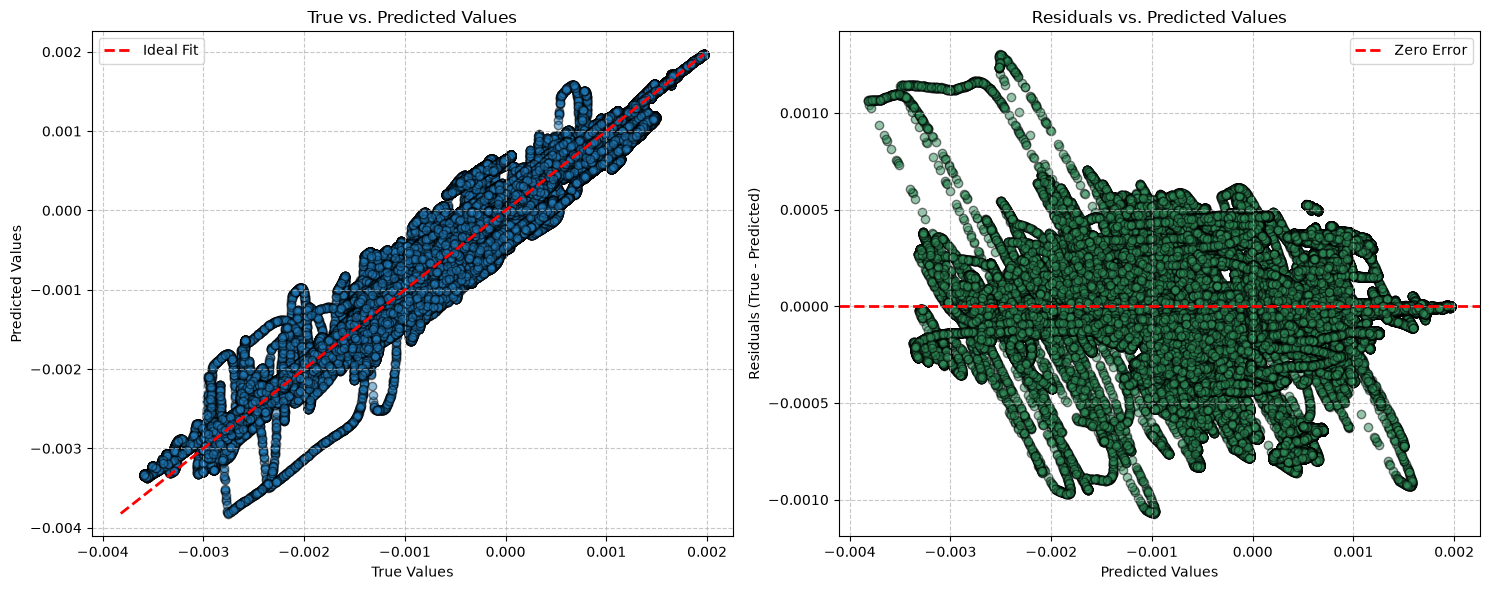

In [105]:
evaluator.eval_model(X_test, y_test, target_names=['x error', 'y error', 'z error'])